In [1]:
from icecube import dataclasses, dataio, icetray, simclasses
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from icecube.phys_services import I3Calculator
import sys, os
import random

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions, get_mc_tree_prop
from plot_helpers import mctree_plot

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

filelistCC = sorted (glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/CC/upgrade_genie_level4_queso_*.i3.zst'))
filelistNC = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/NC/upgrade_genie_level4_queso_*.i3.zst'))

In [3]:
primary_energyCC, secondary_energyCC, azimuthCC, zenithCC, distanceCC, total_chargeCC, total_charge_mCC, yCC = get_mc_tree_prop(random.sample(filelistCC, 2000), ux, uy, uz)
primary_energyNC, secondary_energyNC, azimuthNC, zenithNC, distanceNC, total_chargeNC, total_charge_mNC, yNC = get_mc_tree_prop(random.sample(filelistNC, 4000), ux, uy, uz)

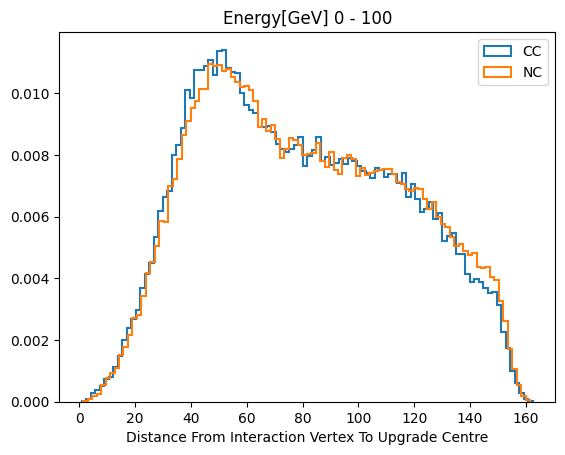

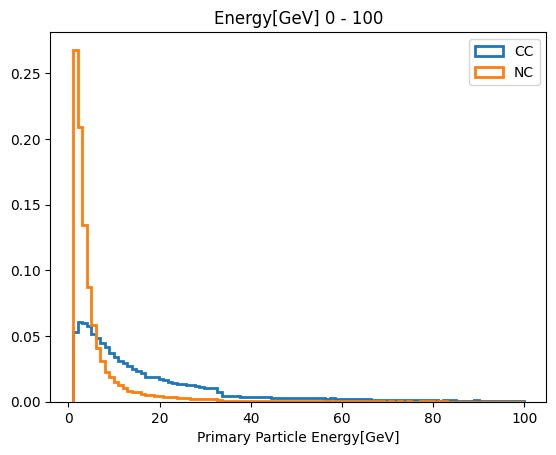

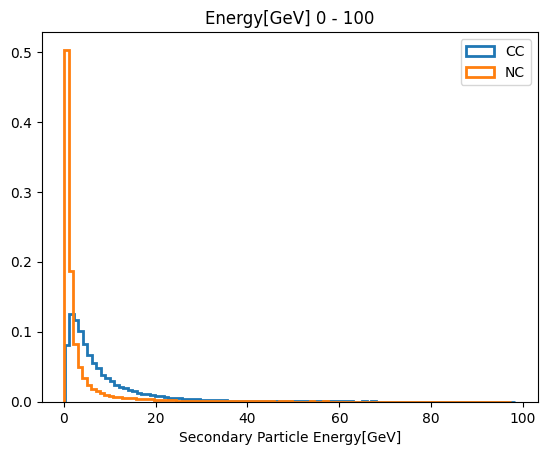

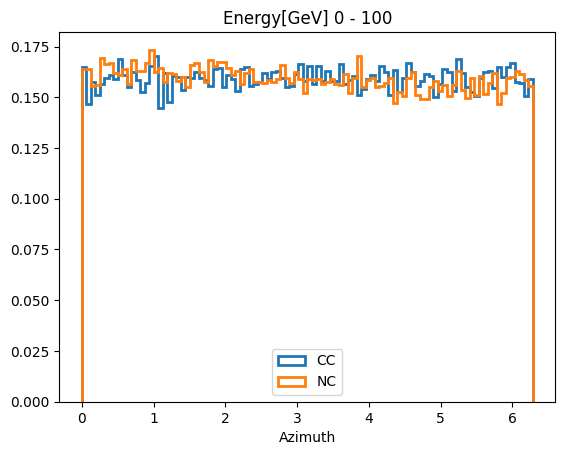

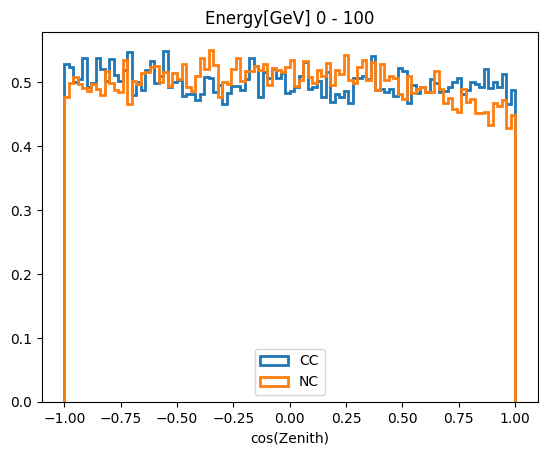

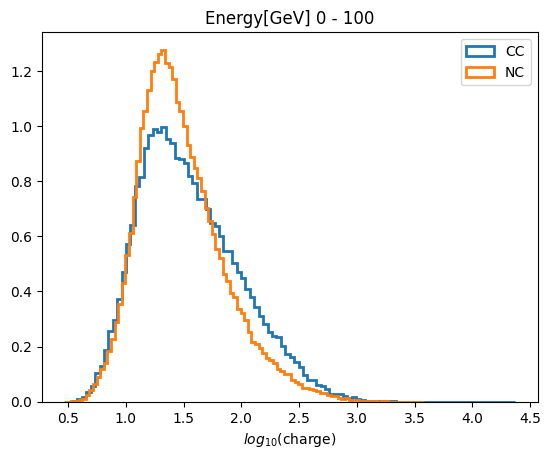

/data/user/akatil/electron_neutrino/for_real/analysis_chain/plot_helpers.py:42: RuntimeWarning: divide by zero encountered in log10
  CC = np.log10(CC[maskCC])
/data/user/akatil/electron_neutrino/for_real/analysis_chain/plot_helpers.py:43: RuntimeWarning: divide by zero encountered in log10
  NC = np.log10(NC[maskNC])


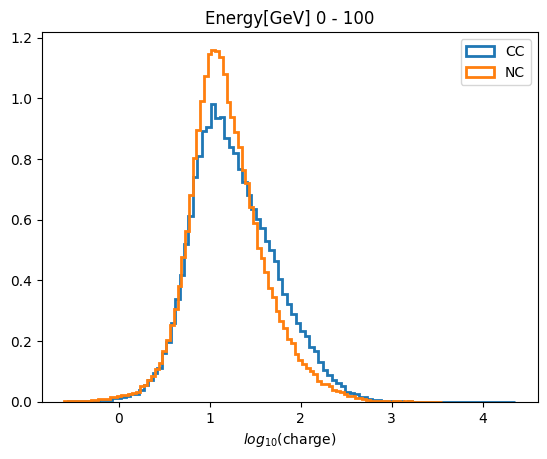

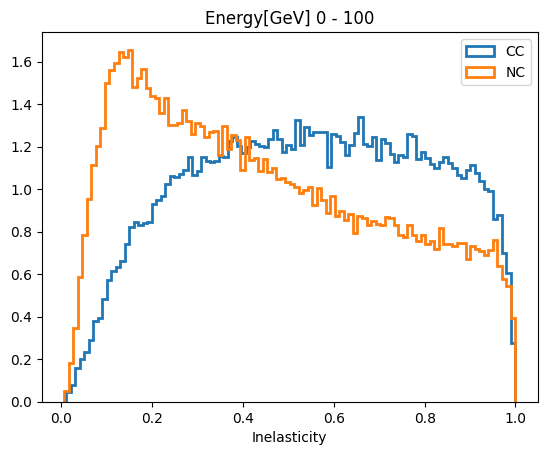

In [4]:
min_val = 0
max_val = 100

mask_data = [secondary_energyCC, secondary_energyNC, total_chargeCC, total_chargeNC, total_charge_mCC, total_charge_mNC]

mctree_plot(distanceCC, distanceNC, mask_data, min_val, max_val, energy=True, 
            lw=1.5, xlabel='Distance From Interaction Vertex To Upgrade Centre')

mctree_plot(primary_energyCC, primary_energyNC, mask_data, min_val, max_val, energy=True,
            xlabel='Primary Particle Energy[GeV]')

mctree_plot(secondary_energyCC, secondary_energyNC, mask_data, min_val, max_val, energy=True,
            xlabel='Secondary Particle Energy[GeV]')

mctree_plot(azimuthCC, azimuthNC, mask_data, min_val, max_val, energy=True, 
            xlabel='Azimuth')

mctree_plot(zenithCC, zenithNC, mask_data, min_val, max_val, energy=True, 
            xlabel='cos(Zenith)')

mctree_plot(total_chargeCC, total_chargeNC, mask_data, min_val, max_val, energy=True, log=True,
           xlabel=r'$log_{10}$(charge)')

mctree_plot(total_charge_mCC, total_charge_mNC, mask_data, min_val, max_val, energy=True, log=True,
           xlabel=r'$log_{10}$(charge)')

mctree_plot(yCC, yNC, mask_data, min_val, max_val, energy=True, log=False,
           xlabel=r'Inelasticity')

In [5]:
'''
Add ineleasticity plots
'''


'''
Add number of events plots with respect to energy and charge
'''



'\nAdd number of events plots with respect to energy and charge\n'